<a href="https://colab.research.google.com/github/rpasquini/econometria/blob/octi-branch/ejercicios/Soluci%C3%B3n_Ejercicio_7_Parte_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

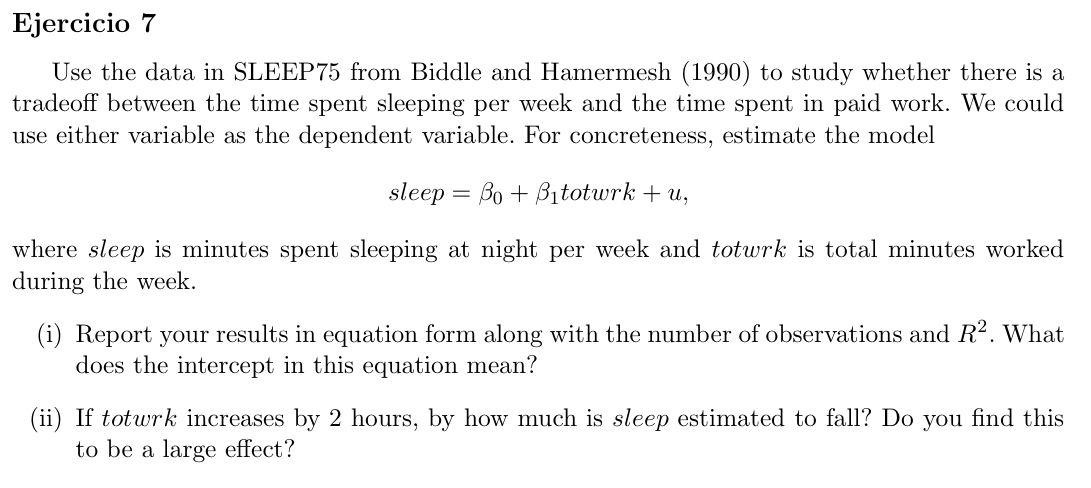

In [21]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [8]:
#importamos el dataset y hacemos print para ver si es lo que necesitamos
df = pd.read_excel('https://github.com/rpasquini/econometria/raw/main/datos/datasets_wooldridge/sleep75.xls')
print(df.head())

   32  0  1  0.1  0.2  12    0.3  0.4  1.1  3529  ...  0.9  3438  0.10 3438.1  \
0  31  0  2  0.0  0.0  14   9500    1    1  2140  ...    0  5020     0   5020   
1  44  0  3  0.0  0.0  17  42500    1    1  4595  ...    1  2815     0   2815   
2  30  0  4  0.0  0.0  12  42500    1    1  3211  ...    1  3786     0   3786   
3  64  0  5  0.0  0.0  14   2500    1    1  4052  ...    1  2580     0   2580   
4  41  0  6  0.0  0.0  12      0    1    1  4812  ...    0  1205     0      0   

   0.11  14  0.12  13  7.070004  1024  
0     0  11     0   0  1.429999   961  
1     0  21     0   0     20.53  1936  
2     0  12     0  12  9.619998   900  
3     0  44     0  33      2.75  4096  
4  1205  23     0  23     19.25  1681  

[5 rows x 34 columns]


In [16]:
#tenemos un problema: los datos no tienen encabezados de columnas. Traeremos las referencias de este archivo: https://github.com/rpasquini/econometria/blob/main/datos/datasets_wooldridge/SLEEP75_description.txt
columnas=["age"     , "black"   , "case"    , "clerical", "construc", "educ"    , "earns74" , "gdhlth"  ,
"inlf"    , "leis1"   , "leis2"   , "leis3"   , "smsa"    , "lhrwage" , "lothinc" , "male"    ,
"marr"    , "prot"    , "rlxall"  , "selfe"   , "sleep"   , "slpnaps" , "south"   , "spsepay" ,
"spwrk75" , "totwrk"  , "union"   , "worknrm" , "workscnd", "exper"   , "yngkid"  , "yrsmarr" ,
"hrwage"  , "agesq"]
#y le indicaremos al programa que estos son los encabezados
df.columns=columnas
df.head()

,age,black,case,clerical,construc,educ,earns74,gdhlth,inlf,leis1,...,spwrk75,totwrk,union,worknrm,workscnd,exper,yngkid,yrsmarr,hrwage,agesq
0,31,0,2,0.0,0.0,14,9500,1,1,2140,...,0,5020,0,5020,0,11,0,0,1.429999,961
1,44,0,3,0.0,0.0,17,42500,1,1,4595,...,1,2815,0,2815,0,21,0,0,20.53,1936
2,30,0,4,0.0,0.0,12,42500,1,1,3211,...,1,3786,0,3786,0,12,0,12,9.619998,900
3,64,0,5,0.0,0.0,14,2500,1,1,4052,...,1,2580,0,2580,0,44,0,33,2.75,4096
4,41,0,6,0.0,0.0,12,0,1,1,4812,...,0,1205,0,0,1205,23,0,23,19.25,1681


In [35]:
#copiamos y pegamos la definición de la función "regress" vista en clase
def regress(lista, data):
  """
  Funcion que realiza la regresion OLS
  lista: Es una lista de nombres variables siendo la primera de ellas la dependiente, el resto son las explicativas
  data: es la base de datos
  print_summary: booleano para indicar si se imprime el summary de la regresion
  """
  datos=data[lista]
  # el metodo dropna() me permite eliminar las filas que tienen algun valor missing
  datos=datos.dropna()
  Y=datos[lista[0]]
  X=datos[lista[1:]]
  X=sm.add_constant(X)
  modelo=sm.OLS(Y,X)
  resultados=modelo.fit()
  print(resultados.summary())
  return resultados

In [22]:
#corremos la regresión del modelo solicitado
regress(['sleep','totwrk'],df)

                            OLS Regression Results                            
Dep. Variable:                  sleep   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     80.85
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           2.23e-18
Time:                        13:08:00   Log-Likelihood:                -5260.1
No. Observations:                 705   AIC:                         1.052e+04
Df Residuals:                     703   BIC:                         1.053e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3586.5119     38.960     92.056      0.0

Con los resultados de la regresión podemos decir que el modelo solicitado tiene la forma sleep = 3586,51 - 0,15 totwrk + u

Si el totwrk aumenta dos horas, es decir, si totwrk aumenta en 120 minutos, entonces sleep caerá por 120 * 0,1508 = 18 minutos aproximadamente

In [23]:
120*0.1508

18.096

In [37]:
#esto también lo podemos hacer utilizando .params para no tener que copiar a mano la cifra del coeficiente de B1
totwrk_coefficient = regress(['sleep','totwrk'],df).params['totwrk']


resultado = totwrk_coefficient * 120
print()
print(f"Aumentar totwrk en 2 horas resulta en {resultado} minutos de sueño perdidos")

                            OLS Regression Results                            
Dep. Variable:                  sleep   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     80.85
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           2.23e-18
Time:                        13:22:17   Log-Likelihood:                -5260.1
No. Observations:                 705   AIC:                         1.052e+04
Df Residuals:                     703   BIC:                         1.053e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3586.5119     38.960     92.056      0.0